In [14]:
import os
import pandas as pd

folder = r"C:\Users\pkwki\OneDrive\Desktop\459 Project\data\fiber_subset"

rows = []

for file in os.listdir(folder):
    if file.endswith(".jpg"):
        name = file.replace(".jpg", "")
        axx, ayy, azz = map(float, name.split(","))

        csv_file = name + ".csv"

        rows.append({
            "image_file": file,
            "csv_file": csv_file,
            "a_xx": axx,
            "a_yy": ayy,
            "a_zz": azz
        })

df = pd.DataFrame(rows)

print(df.shape)
print(df.head())

(1507, 5)
                 image_file                  csv_file    a_xx    a_yy    a_zz
0  0.0030,0.5303,0.4667.jpg  0.0030,0.5303,0.4667.csv  0.0030  0.5303  0.4667
1  0.0031,0.5649,0.4320.jpg  0.0031,0.5649,0.4320.csv  0.0031  0.5649  0.4320
2  0.0037,0.5458,0.4505.jpg  0.0037,0.5458,0.4505.csv  0.0037  0.5458  0.4505
3  0.0037,0.6071,0.3892.jpg  0.0037,0.6071,0.3892.csv  0.0037  0.6071  0.3892
4  0.0038,0.4358,0.5605.jpg  0.0038,0.4358,0.5605.csv  0.0038  0.4358  0.5605


In [15]:
sample_csv = os.path.join(folder, df.iloc[0]['csv_file'])

fiber_df = pd.read_csv(sample_csv)

print(fiber_df.head())
print(fiber_df.columns)
print(fiber_df.shape)

            x           y         a           b         phi  aspect_ratio  \
0  200.439703  186.172377  8.406087  184.122210  135.768587     21.903438   
1   64.985911  264.992333  7.818242  141.844370  118.755492     18.142746   
2  406.784887   -1.567102  8.272723  186.237669  132.391038     22.512257   
3   63.010513   -4.116481  7.598545  184.524943   84.661715     24.284248   
4  239.602097   73.533471  8.032354  180.161097   25.880102     22.429426   

   beta_deg  ellipse_area  intersection_area  width  ...  a_variation  \
0  2.616745   1215.597903        1215.109784    510  ...            1   
1  3.159656    870.985802         870.636060    510  ...            1   
2  2.545930   1210.057191         585.584866    510  ...            1   
3  2.360048   1101.223266         146.190430    510  ...            1   
4  2.555339   1136.563624        1117.121955    510  ...            1   

   max_attempts  total_attempts  num_ellipses  target_area   final_area  \
0        500000        

In [16]:
import numpy as np

feature_rows = []

for idx, row in df.iterrows():

    csv_path = os.path.join(folder, row['csv_file'])

    fiber_df = pd.read_csv(csv_path)

    features = {

        # Fiber count
        'num_fibers': len(fiber_df),

        # Orientation statistics
        'phi_mean': fiber_df['phi'].mean(),
        'phi_std': fiber_df['phi'].std(),

        # Aspect ratio statistics
        'aspect_mean': fiber_df['aspect_ratio'].mean(),
        'aspect_std': fiber_df['aspect_ratio'].std(),

        # Fiber size statistics
        'area_mean': fiber_df['ellipse_area'].mean(),
        'area_std': fiber_df['ellipse_area'].std(),

        # Packing
        'packing_fraction': fiber_df['p_achieved'].iloc[0],

        # Labels
        'a_xx': row['a_xx'],
        'a_yy': row['a_yy'],
        'a_zz': row['a_zz']
    }

    feature_rows.append(features)

ml_df = pd.DataFrame(feature_rows)

print(ml_df.head())
print(ml_df.shape)

   num_fibers   phi_mean    phi_std  aspect_mean  aspect_std   area_mean  \
0          17  71.534180  44.418978    19.857115    4.343629  984.830941   
1          15  71.548546  41.776954    19.732347    4.556867  965.324276   
2          18  86.251841  48.776114    19.234720    5.643353  884.370559   
3          17  87.430079  44.035962    17.792296    4.315468  892.953967   
4          15  97.268009  58.687636    18.453513    5.160067  882.492969   

     area_std  packing_fraction    a_xx    a_yy    a_zz  
0  198.957910          0.062771  0.0030  0.5303  0.4667  
1  185.074659          0.063945  0.0031  0.5649  0.4320  
2  268.437705          0.061425  0.0037  0.5458  0.4505  
3  229.490101          0.062074  0.0037  0.6071  0.3892  
4  207.179909          0.060049  0.0038  0.4358  0.5605  
(1507, 11)


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

# Features
X = ml_df.drop(columns=['a_xx', 'a_yy', 'a_zz'])

# Targets
y = ml_df[['a_xx', 'a_yy', 'a_zz']]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Model
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train
model.fit(X_train, y_train)

# Predict
pred = model.predict(X_test)

# Metrics
r2 = r2_score(y_test, pred)
mae = mean_absolute_error(y_test, pred)

print("R2 Score:", r2)
print("MAE:", mae)

R2 Score: 0.9985710424658993
MAE: 0.0010850838852097132


            feature  importance
2           phi_std    0.633715
7  packing_fraction    0.354822
1          phi_mean    0.004743
4        aspect_std    0.001548
3       aspect_mean    0.001488
5         area_mean    0.001345
0        num_fibers    0.001210
6          area_std    0.001129


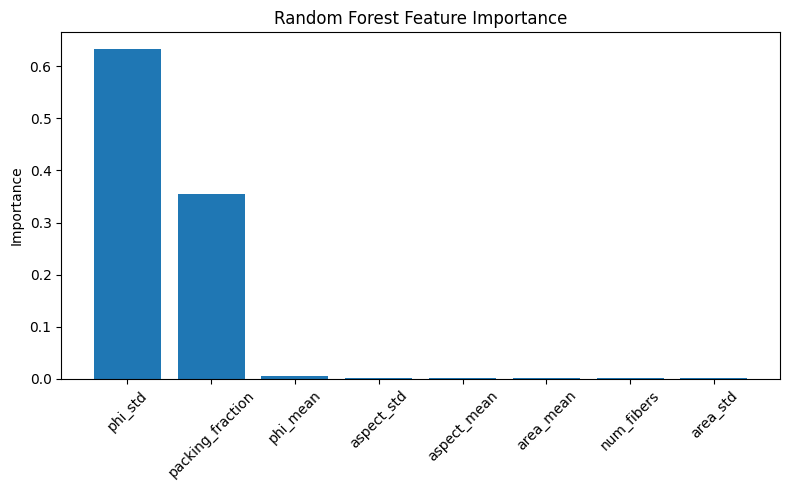

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

importance = model.feature_importances_

feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importance
})

feature_importance_df = feature_importance_df.sort_values(
    by='importance',
    ascending=False
)

print(feature_importance_df)

plt.figure(figsize=(8,5))
plt.bar(feature_importance_df['feature'],
        feature_importance_df['importance'])

plt.xticks(rotation=45)
plt.ylabel("Importance")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# Remove orientation-related descriptors
X2 = ml_df.drop(columns=[
    'phi_mean',
    'phi_std',
    'a_xx',
    'a_yy',
    'a_zz'
])

# Targets
y2 = ml_df[['a_xx', 'a_yy', 'a_zz']]

# Train/test split
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2,
    y2,
    test_size=0.2,
    random_state=42
)

# Random Forest model
model2 = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train
model2.fit(X_train2, y_train2)

# Predict
pred2 = model2.predict(X_test2)

# Metrics
r2_2 = r2_score(y_test2, pred2)
mae_2 = mean_absolute_error(y_test2, pred2)

print("R2 Score without phi features:", r2_2)
print("MAE without phi features:", mae_2)

R2 Score without phi features: 0.9954790360579416
MAE without phi features: 0.005641590507726259


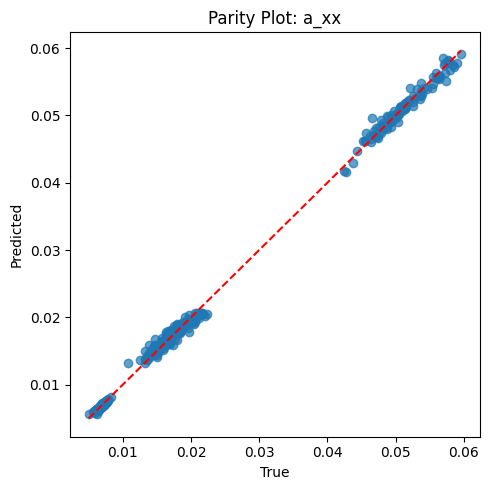

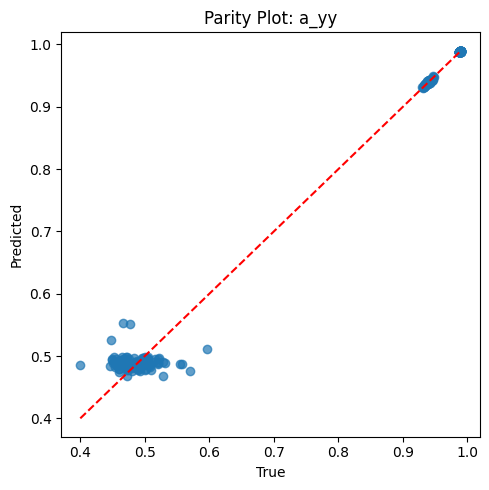

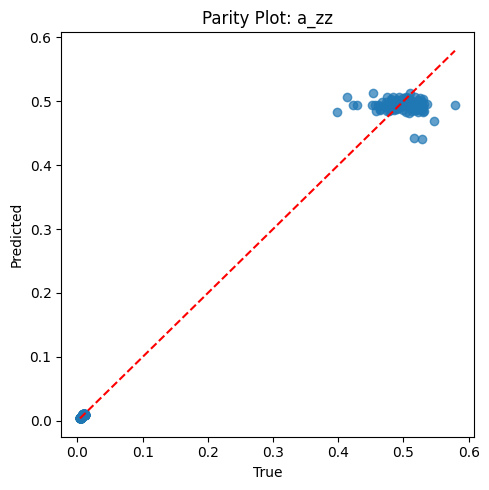

In [20]:
import matplotlib.pyplot as plt

labels = ['a_xx', 'a_yy', 'a_zz']

for i in range(3):

    plt.figure(figsize=(5,5))

    plt.scatter(
        y_test2.iloc[:, i],
        pred2[:, i],
        alpha=0.7
    )

    plt.plot(
        [y_test2.iloc[:, i].min(), y_test2.iloc[:, i].max()],
        [y_test2.iloc[:, i].min(), y_test2.iloc[:, i].max()],
        'r--'
    )

    plt.xlabel("True")
    plt.ylabel("Predicted")

    plt.title(f"Parity Plot: {labels[i]}")

    plt.tight_layout()
    plt.show()

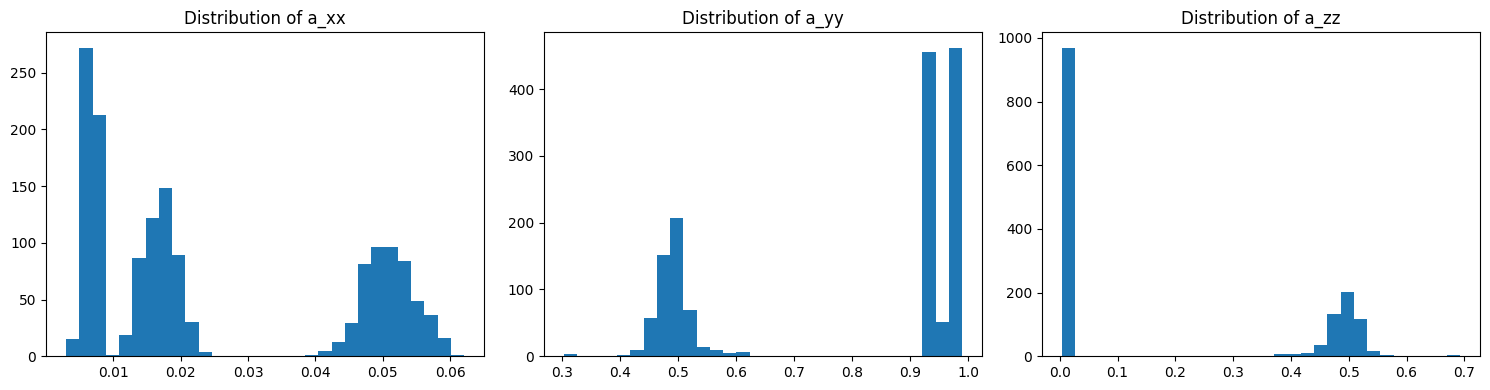

In [21]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15,4))

axes[0].hist(ml_df['a_xx'], bins=30)
axes[0].set_title('Distribution of a_xx')

axes[1].hist(ml_df['a_yy'], bins=30)
axes[1].set_title('Distribution of a_yy')

axes[2].hist(ml_df['a_zz'], bins=30)
axes[2].set_title('Distribution of a_zz')

plt.tight_layout()
plt.show()